# 1.1 Importation des bibliothèques

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
!pip install pyarabic

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.4/126.4 kB 4.3 MB/s eta 0:00:00


In [6]:
import pandas as pd
import numpy as np
import re
import torch
from transformers import BertTokenizer, BertForSequenceClassification
from sklearn.model_selection import train_test_split
from pyarabic import araby
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from torch.utils.data import DataLoader, Dataset
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from transformers import AutoTokenizer, AutoModel
from sklearn import preprocessing
from torch.optim import AdamW
from torch import nn
from torch.utils.data import TensorDataset, DataLoader
from transformers import get_linear_schedule_with_warmup
import gc
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import WeightedRandomSampler
from sklearn.svm import SVC

# 1.2 Importation des données

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/datasets/MAC_corpus.csv")

# suppression de la classe mixed
df = df[df['type'] != 'mixed']
df.head()

,tweets,type,class
0,ماهي آرائكم متتبعي الكرام,neutral,standard
1,عبقرية المدرب وروعة اللاعبين,positive,standard
2,أمة عربية واحدة خالدة,positive,standard
3,عاد إليكم من جديد وأخيرا درت جيم لهاد الصفحة,neutral,dialectal
4,الله يخلف عليك سيدي محمد,positive,dialectal


# 1.3 exploration des données

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 17444 entries, 0 to 18086
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   tweets  17441 non-null  object
 1   type    17444 non-null  object
 2   class   17444 non-null  object
dtypes: object(3)
memory usage: 545.1+ KB


In [ ]:
df.describe()

,tweets,type,class
count,17441,17444,17444
unique,12176,3,3
top,الله يحفظك,positive,standard
freq,39,9897,12151


In [ ]:
# nbr d'entrees
df.shape[0]

17444

In [ ]:
# nbr de colonne
df.shape[1]

3

In [ ]:
def summary_types(df: pd.DataFrame) -> str:
    """Retourne un résumé compact des types : ex. 'int64 (2), object (1)'."""
    df_conv = df.copy()

    # Tentative de conversion des colonnes object → numérique si elles le peuvent
    for col in df_conv.select_dtypes(include='object'):
        try:
            df_conv[col] = pd.to_numeric(df_conv[col], errors='raise')
        except (ValueError, TypeError):
            # La colonne contient autre chose que des chiffres : on la laisse en object
            pass

    # Comptage des types après conversion éventuelle
    counts = df_conv.dtypes.value_counts()
    return ", ".join(f"{dtype} ({cnt})" for dtype, cnt in counts.items())

# --- utilisation ---
print(summary_types(df))


object (3)


In [ ]:
# df est ton DataFrame
# Remplace 'type' par le nom réel de la colonne cible si besoin
counts = df["type"].value_counts()                 # nombre d’exemplaires
percents = df["type"].value_counts(normalize=True) # proportion en %

print("Counts :\n", counts, "\n")
print("Pourcentages :\n", (percents * 100).round(2))


Counts :
 type
positive    9897
neutral     4039
negative    3508
Name: count, dtype: int64 

Pourcentages :
 type
positive    56.74
neutral     23.15
negative    20.11
Name: proportion, dtype: float64


In [ ]:
nombre_doublons = df.duplicated().sum()   # doublons exacts sur toutes les colonnes
print("Nombre de doublons :", nombre_doublons)

Nombre de doublons : 5197


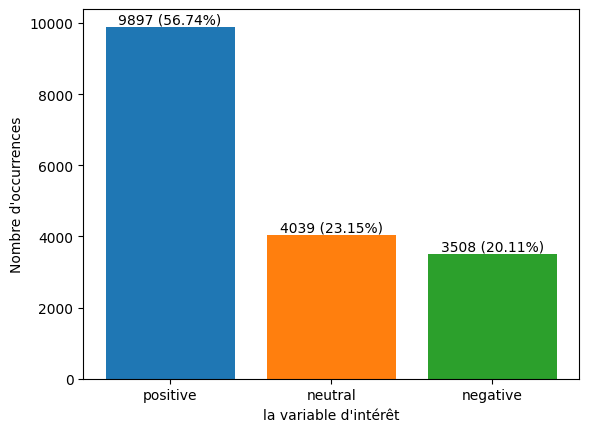

In [ ]:
colors = plt.cm.tab10.colors
type_counts= df['type'].value_counts()
color_list = colors[:len(type_counts)]

plt.bar(type_counts.index, type_counts.values, color = color_list)
sentiment_proportions = df['type'].value_counts(normalize=True)
for i, count in enumerate(type_counts):
    proportion = sentiment_proportions.iloc[i]
    plt.text(i, count, f"{count} ({proportion:.2%})", ha='center', va='bottom')

plt.xlabel('la variable d\'intérêt')
plt.ylabel('Nombre d\'occurrences')
plt.show()

In [ ]:
df.isnull().sum()

,0
tweets,3
type,0
class,0


In [ ]:
df.dropna(inplace=True)

In [ ]:
df.isnull().sum()

,0
tweets,0
type,0
class,0


# 1.4 prétraitement du jeu de donnees

In [ ]:
# renommer la colonne type
df.rename(columns={'type': 'sentiment'}, inplace=True)

In [ ]:
df = df[['tweets','sentiment']]
df

,tweets,sentiment
0,ماهي آرائكم متتبعي الكرام,neutral
1,عبقرية المدرب وروعة اللاعبين,positive
2,أمة عربية واحدة خالدة,positive
3,عاد إليكم من جديد وأخيرا درت جيم لهاد الصفحة,neutral
4,الله يخلف عليك سيدي محمد,positive
...,...,...
18082,ريالية و افتخر و نعلي راسي الفوق,positive
18083,ماكاين مشكل,positive
18084,سمح ليا ماقصدتش,positive
18085,الله يكمل عليها بالخير,positive


In [ ]:
num_duplicates = df.duplicated().sum()
print(f"nombre de lignes dupliquees : {num_duplicates}")

nombre de lignes dupliquees : 5223


# 1.5 Visualisation des données ( La distribution des classes)

In [ ]:
# la distribution des classes dans la colonne sentiment
sentiment_counts= df['sentiment'].value_counts()
print(sentiment_counts)

sentiment
positive    9894
neutral     4039
negative    3508
Name: count, dtype: int64


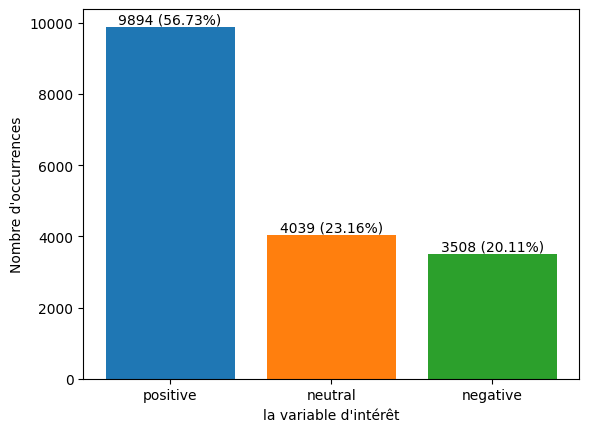

In [ ]:
colors = plt.cm.tab10.colors
color_list = colors[:len(sentiment_counts)]

plt.bar(sentiment_counts.index, sentiment_counts.values, color = color_list)
sentiment_proportions = df['sentiment'].value_counts(normalize=True)
for i, count in enumerate(sentiment_counts):
    proportion = sentiment_proportions.iloc[i]
    plt.text(i, count, f"{count} ({proportion:.2%})", ha='center', va='bottom')

plt.xlabel('la variable d\'intérêt')
plt.ylabel('Nombre d\'occurrences')
plt.show()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 17441 entries, 0 to 18086
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   tweets     17441 non-null  object
 1   sentiment  17441 non-null  object
dtypes: object(2)
memory usage: 408.8+ KB


In [ ]:
df.describe()

,tweets,sentiment
count,17441,17441
unique,12176,3
top,الله يحفظك,positive
freq,39,9894


In [ ]:


# Si df provient d’un filtrage, sécurise-le d’abord :
df = df.copy()

# 1) S’assurer que la colonne 'tweets' est bien du texte
#    - On remplace les valeurs manquantes par une chaîne vide
#    - On caste tout en str
df["tweets"] = df["tweets"].fillna("").astype(str)

# 2) Longueur en caractères
df["char_len"] = df["tweets"].str.len()

# 3) Longueur en mots (splits simples sur l’espace)
df["word_len"] = df["tweets"].str.split().str.len()

# ------------------ Statistiques caractères ------------------
mean_chars       = df["char_len"].mean()
max_chars        = df["char_len"].max()
min_chars        = df["char_len"].min()
quantile99_chars = df["char_len"].quantile(0.99)

# -------------------- Statistiques mots ----------------------
mean_words       = df["word_len"].mean()
max_words        = df["word_len"].max()
min_words        = df["word_len"].min()
quantile99_words = df["word_len"].quantile(0.99)

# ------------------ Vocabulaire unique -----------------------
unique_words = set(" ".join(df["tweets"]).split())
vocab_size   = len(unique_words)

# --------------------------- Affichage ------------------------
print(f"Nombre moyen de caractères : {mean_chars:.0f}")
print(f"Tweet le plus long         : {max_chars} caractères")
print(f"Tweet le plus court        : {min_chars} caractères")
print(f"Nbre de caractères, q=0.99 : {quantile99_chars:.0f}\n")

print(f"Nombre moyen de mots       : {mean_words:.0f}")
print(f"Tweet le plus long         : {max_words} mots")
print(f"Tweet le plus court        : {min_words} mot")
print(f"Nbre de mots, q=0.99       : {quantile99_words:.0f}\n")

print(f"Nombre de mots uniques     : {vocab_size}")


Nombre moyen de caractères : 43
Tweet le plus long         : 278 caractères
Tweet le plus court        : 1 caractères
Nbre de caractères, q=0.99 : 215

Nombre moyen de mots       : 8
Tweet le plus long         : 57 mots
Tweet le plus court        : 0 mot
Nbre de mots, q=0.99       : 40

Nombre de mots uniques     : 28499


# 1.6 Stop words

In [ ]:
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
# charger la liste des stop words en arabe depuis nltk
stop_words = set(stopwords.words('arabic'))

# fonction pour supprimer les stop words
def remove_stop_words(text, stop_words):
    words = text.split()
    filtered_words = [word for word in words if word not in stop_words]
    return ' '.join(filtered_words)



# 1.7 nettoyage specifique au texte (en arabe)

In [ ]:
from nltk.stem.isri import ISRIStemmer
stemmer = ISRIStemmer()

def clean(text):
    if isinstance(text, float):
        text = ""
    text = text.replace("<br/>", " ")
    strip_special_chars = re.compile(u'[^\u0621-\u064a ]')
    return re.sub(strip_special_chars, " ", text)

def apply_stemming(text):
    words = text.split()
    stemmed_words = [stemmer.stem(word) for word in words]
    return ' '.join(stemmed_words)

def process(text):
    if isinstance(text, float):
        text = ""
    text = remove_stop_words(text, stop_words)
    text = araby.strip_tashkeel(text)
    text = re.sub('\ـ+', ' ', text)
    text = re.sub('\ر+', 'ر', text)
    text = re.sub('\اا+', 'ا', text)
    text = re.sub('\ووو+', 'و', text)
    text = re.sub('\ههه+', 'ههه', text)
    text = re.sub('\ةة+', 'ة', text)
    text = re.sub('\ييي+', 'ي', text)
    text = re.sub('أ', 'ا', text)
    text = re.sub('آ', 'ا', text)
    text = re.sub('إ', 'ا', text)
    text = re.sub('ة', 'ه', text)
    text = re.sub('ى', 'ي', text)
    text = " ".join(text.split())
    text = apply_stemming(text)
    return text



In [ ]:
# application des fonction clean et process sur la colone twetts
df['clean_text'] = df['tweets'].apply(lambda cw: clean(cw))
df['clean_text_process'] = df['clean_text'].apply(lambda cw: process(cw))
# affichage de la colonne twetts netoye
print(df['clean_text_process'])

0            اهي ارئ تبع كرم
1           عبقر درب ورع لعب
2            امه عرب وحد خلد
3        جدد اخر درت لهد صفح
4            الل خلف سيد حمد
                ...         
18082    ريل فخر نعل رسي فوق
18083                اكا شكل
18084        سمح ليا ماقصدتش
18085      الل كمل عليها خير
18086           يمكن الل علم
Name: clean_text_process, Length: 17441, dtype: object


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 17441 entries, 0 to 18086
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   tweets              17441 non-null  object
 1   sentiment           17441 non-null  object
 2   char_len            17441 non-null  int64 
 3   word_len            17441 non-null  int64 
 4   clean_text          17441 non-null  object
 5   clean_text_process  17441 non-null  object
dtypes: int64(2), object(4)
memory usage: 953.8+ KB


In [ ]:
len(df)

17441

In [ ]:
df.count()

,0
tweets,17441
sentiment,17441
char_len,17441
word_len,17441
clean_text,17441
clean_text_process,17441


In [ ]:
df.shape[0]

17441

# 1.8 La transformation en list

In [ ]:
# renisalisation des index
df = df.reset_index(drop=True)
# transformation en list
text_list = df['clean_text_process'].tolist()
text_list[17440]

'يمكن الل علم'

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17441 entries, 0 to 17440
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   tweets              17441 non-null  object
 1   sentiment           17441 non-null  object
 2   char_len            17441 non-null  int64 
 3   word_len            17441 non-null  int64 
 4   clean_text          17441 non-null  object
 5   clean_text_process  17441 non-null  object
dtypes: int64(2), object(4)
memory usage: 817.7+ KB


# 1.9 l'encodage

In [ ]:
sentiment = df['sentiment']
print(sentiment)
# application de l'encodage sur la colonne sentiment "label encoding"
label_encoder = preprocessing.LabelEncoder()
y = label_encoder.fit_transform(df['sentiment'])
print(y)
class_names = label_encoder.classes_

0         neutral
1        positive
2        positive
3         neutral
4        positive
           ...   
17436    positive
17437    positive
17438    positive
17439    positive
17440     neutral
Name: sentiment, Length: 17441, dtype: object
[1 2 2 ... 2 2 1]


In [ ]:
# data split : 70% pour l'entrainement et 30% pour le test
x_train, x_temp, y_train, y_temp = train_test_split(text_list, y, test_size=0.30, random_state=42)
# data split : deux tiers pour le test et un tier pour la validation
x_val, x_test, y_val, y_test = train_test_split(x_temp, y_temp, test_size=2/3, random_state=42)

In [ ]:
print("Unique values in Y_train:", np.unique(y_train))
print("Unique values in Y_test:", np.unique(y_test))
print("Unique values in Y_val:", np.unique(y_val))

Unique values in Y_train: [0 1 2]
Unique values in Y_test: [0 1 2]
Unique values in Y_val: [0 1 2]


# 2. Embeddings

In [ ]:
tokenizer = AutoTokenizer.from_pretrained("aubmindlab/bert-base-arabertv02")
bert_model = AutoModel.from_pretrained("aubmindlab/bert-base-arabertv02")

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/381 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/384 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/825k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.64M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/543M [00:00<?, ?B/s]

In [ ]:
def compute_bert_embeddings(texts, tokenizer, bert_model, device, max_len=128, batch_size=16):

    bert_model = bert_model.to(device)  # force le modele sur le bon device
    bert_model.eval()
    all_embeddings = []
    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i:i + batch_size]
        # tokenization (sur CPU)
        encoding = tokenizer(
            batch_texts,
            truncation=True,
            padding='max_length',
            max_length=max_len,
            return_tensors='pt'
        )
        # deplacement explicite vers le GPU
        input_ids = encoding['input_ids'].to(device)
        attention_mask = encoding['attention_mask'].to(device)
        with torch.no_grad():
            outputs = bert_model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )
            # recupere les embeddings [CLS]
            cls_embeddings = outputs.last_hidden_state[:, 0, :]
            all_embeddings.append(cls_embeddings.cpu())  # retourne en CPU pour economiser la memoire GPU

    return torch.cat(all_embeddings, dim=0)

In [ ]:
# pre-calculer toutes les embeddings avant l'entrainement
device = torch.device('cuda' if torch.cuda.is_available() else 'T4 GPU')
print("\nComputing ArabicBERT embeddings for train, val, and test sets...")

train_embeddings = compute_bert_embeddings(x_train, tokenizer, bert_model, device)
val_embeddings = compute_bert_embeddings(x_val, tokenizer, bert_model, device)
test_embeddings = compute_bert_embeddings(x_test, tokenizer, bert_model, device)

print("Embeddings computed successfully.")


Computing ArabicBERT embeddings for train, val, and test sets...
Embeddings computed successfully.


# 3. Classifiers

In [ ]:
def plot_learning_curves(train_losses, val_losses, train_accs, val_accs):
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Validation Loss')
    plt.title('Evolution des Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(train_accs, label='Train Accuracy')
    plt.plot(val_accs, label='Validation Accuracy')
    plt.title('Evolution des Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.show()

def print_classification_report(y_true, y_pred, target_names=None):
    print("rapport de classification ")
    print("")
    print(classification_report(y_true, y_pred, target_names=target_names))

def plot_confusion_matrix(y_true, y_pred, classes, title='Matrice de Confusion'):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes,
                yticklabels=classes)
    plt.xlabel('Prédictions')
    plt.ylabel('Vraies étiquettes')
    plt.title(title)
    plt.show()



## 3.1 LSTM

In [ ]:
# definir le modele LSTM
class LSTMModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, num_layers=1, dropout=0.2):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers=num_layers,
                            batch_first=True, bidirectional=False, dropout=dropout)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        lstm_out, (hidden, cell) = self.lstm(x)
        out = self.dropout(lstm_out[:, -1, :])
        out = self.fc(out)
        return out

# parametres du modelee
INPUT_DIM = train_embeddings.size(1)
HIDDEN_DIM = 256
OUTPUT_DIM = len(np.unique(y_train))
NUM_LAYERS = 1
DROPOUT = 0.8
BATCH_SIZE = 64
LEARNING_RATE = 1e-4
EPOCHS = 50

# initialiser le modele
model = LSTMModel(INPUT_DIM, HIDDEN_DIM, OUTPUT_DIM, NUM_LAYERS, DROPOUT).to(device)
# fonction de perte et optimiseur
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
# preparer les donnees pour DataLoader
train_data = TensorDataset(train_embeddings.unsqueeze(1), torch.tensor(y_train, dtype=torch.long))
val_data = TensorDataset(val_embeddings.unsqueeze(1), torch.tensor(y_val, dtype=torch.long))
test_data = TensorDataset(test_embeddings.unsqueeze(1), torch.tensor(y_test, dtype=torch.long))

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_data, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_data, batch_size=BATCH_SIZE)

# fonction pour calculer la precision
def calculate_accuracy(y_pred, y_true):
    _, predicted = torch.max(y_pred, 1)
    correct = (predicted == y_true).float()
    accuracy = correct.sum() / len(correct)
    return accuracy

# boucle d'entrainement
train_losses = []
val_losses = []
train_accs = []
val_accs = []

for epoch in range(EPOCHS):
    model.train()
    epoch_train_loss = 0
    epoch_train_acc = 0

    for batch in train_loader:
        x_batch, y_batch = batch
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        y_pred = model(x_batch)
        loss = criterion(y_pred, y_batch)
        acc = calculate_accuracy(y_pred, y_batch)

        loss.backward()
        optimizer.step()

        epoch_train_loss += loss.item()
        epoch_train_acc += acc.item()

    # validation
    model.eval()
    epoch_val_loss = 0
    epoch_val_acc = 0

    with torch.no_grad():
        for batch in val_loader:
            x_batch, y_batch = batch
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)

            y_pred = model(x_batch)
            loss = criterion(y_pred, y_batch)
            acc = calculate_accuracy(y_pred, y_batch)

            epoch_val_loss += loss.item()
            epoch_val_acc += acc.item()

    # calcul des moyennes
    train_loss = epoch_train_loss / len(train_loader)
    train_acc = epoch_train_acc / len(train_loader)
    val_loss = epoch_val_loss / len(val_loader)
    val_acc = epoch_val_acc / len(val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f'Epoch {epoch+1}/{EPOCHS}:')
    print(f'Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}')
    print(f'Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}')
    print('-' * 50)

/usr/local/lib/python3.11/dist-packages/torch/nn/modules/rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.8 and num_layers=1
  warnings.warn(


Epoch 1/50:
Train Loss: 0.9209 | Train Acc: 0.57
Val Loss: 0.8311 | Val Acc: 0.61
--------------------------------------------------
Epoch 2/50:
Train Loss: 0.8045 | Train Acc: 0.64
Val Loss: 0.7733 | Val Acc: 0.65
--------------------------------------------------
Epoch 3/50:
Train Loss: 0.7684 | Train Acc: 0.66
Val Loss: 0.7474 | Val Acc: 0.68
--------------------------------------------------
Epoch 4/50:
Train Loss: 0.7494 | Train Acc: 0.67
Val Loss: 0.7334 | Val Acc: 0.68
--------------------------------------------------
Epoch 5/50:
Train Loss: 0.7278 | Train Acc: 0.68
Val Loss: 0.7228 | Val Acc: 0.68
--------------------------------------------------
Epoch 6/50:
Train Loss: 0.7166 | Train Acc: 0.69
Val Loss: 0.7145 | Val Acc: 0.69
--------------------------------------------------
Epoch 7/50:
Train Loss: 0.7060 | Train Acc: 0.70
Val Loss: 0.7089 | Val Acc: 0.69
--------------------------------------------------
Epoch 8/50:
Train Loss: 0.6999 | Train Acc: 0.69
Val Loss: 0.7053 | V

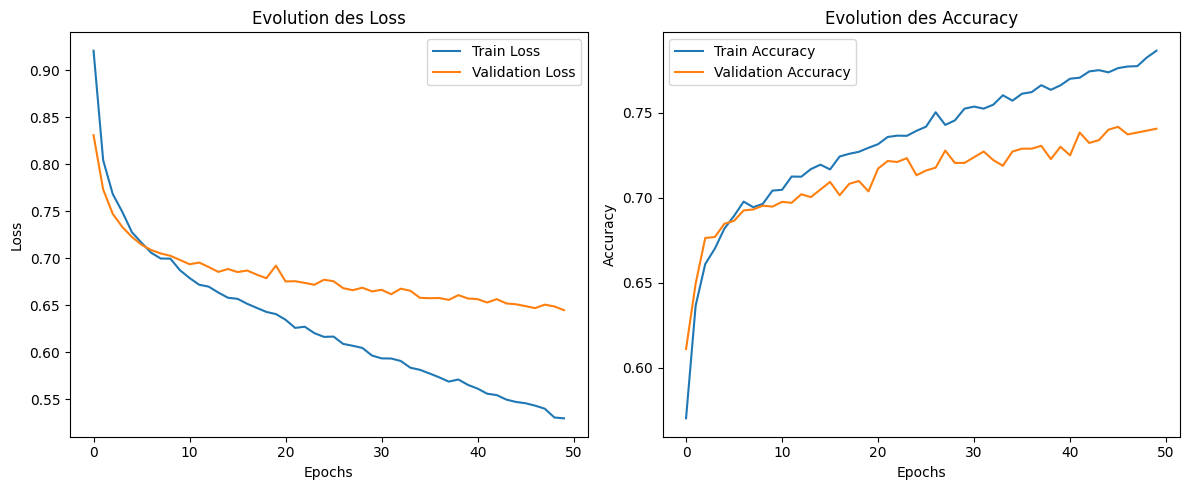

In [ ]:
# visualisation courbes
plot_learning_curves(train_losses, val_losses, train_accs, val_accs)
# evaluation sur le test set
model.eval()
test_loss = 0
test_acc = 0
all_preds = []
all_true = []

with torch.no_grad():
    for batch in test_loader:
        x_batch, y_batch = batch
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)

        y_pred = model(x_batch)
        loss = criterion(y_pred, y_batch)
        acc = calculate_accuracy(y_pred, y_batch)

        test_loss += loss.item()
        test_acc += acc.item()
        all_preds.extend(torch.argmax(y_pred, 1).cpu().numpy())
        all_true.extend(y_batch.cpu().numpy())
test_acc /= len(test_loader)

rapport de classification 

              precision    recall  f1-score   support

    negative       0.66      0.63      0.65       703
     neutral       0.57      0.54      0.56       808
    positive       0.81      0.85      0.83      1978

    accuracy                           0.73      3489
   macro avg       0.68      0.67      0.68      3489
weighted avg       0.73      0.73      0.73      3489



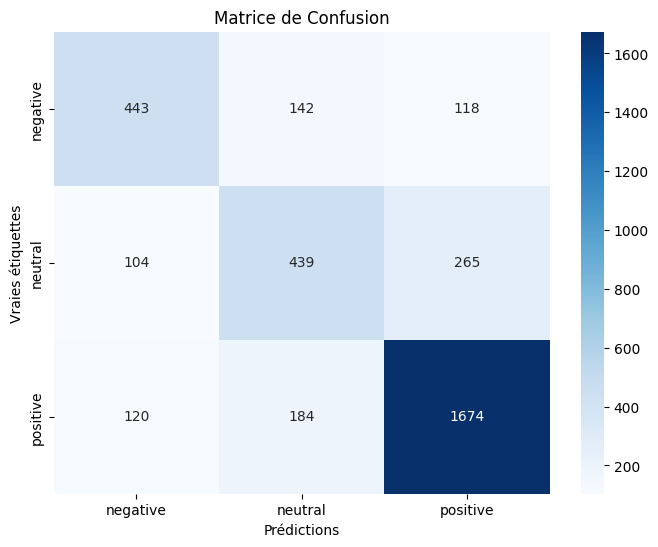

In [ ]:
# rapport et matrice
print_classification_report(all_true, all_preds, target_names=label_encoder.classes_)
plot_confusion_matrix(all_true, all_preds, classes=label_encoder.classes_)

In [ ]:
# fonction de prediction
def predict_from_texts(texts):
    embeddings = compute_bert_embeddings(texts, tokenizer, bert_model, device)
    embeddings = embeddings.unsqueeze(1).to(device)  # forme (batch, seq_len=1, input_dim)
    with torch.no_grad():
        outputs = model(embeddings)
        preds_idx = torch.argmax(outputs, dim=1).cpu().numpy()
    preds_labels = label_encoder.inverse_transform(preds_idx)
    return preds_labels

texts_darija = [
    # exemples positifs
    "فرحان بزاف بهاد النتيجة",
    "المساعدة كانت ممتازة وسريعة",
    "شكراً لكم على كل شيء",
    "هذا المنتج رائع وعجبني كثيراً",
    "كنت سعيد بالتجربة ديالي معاكم",

    # exemples negatifs
    "هاد الخدمة خايبة وما عجباتنيش",
    "عندي مشكل مع الهاتف ديالي وما تحلش",
    "ما بغيتش نرجع نستعمل هاد التطبيق",
    "التجربة ديالي كانت سيئة بزاف",
    "ما لقيتش الدعم اللي كنت كنطلبو",
]
predictions = predict_from_texts(texts_darija)
for text, pred in zip(texts_darija, predictions):
    print(f"Texte : {text}\nPrédiction : {pred}\n")

Texte : فرحان بزاف بهاد النتيجة
Prédiction : positive

Texte : المساعدة كانت ممتازة وسريعة
Prédiction : positive

Texte : شكراً لكم على كل شيء
Prédiction : positive

Texte : هذا المنتج رائع وعجبني كثيراً
Prédiction : positive

Texte : كنت سعيد بالتجربة ديالي معاكم
Prédiction : positive

Texte : هاد الخدمة خايبة وما عجباتنيش
Prédiction : neutral

Texte : عندي مشكل مع الهاتف ديالي وما تحلش
Prédiction : neutral

Texte : ما بغيتش نرجع نستعمل هاد التطبيق
Prédiction : neutral

Texte : التجربة ديالي كانت سيئة بزاف
Prédiction : negative

Texte : ما لقيتش الدعم اللي كنت كنطلبو
Prédiction : neutral



## 3.2 BiLSTM

In [ ]:
# definir le modele BiLSTM
class BiLSTMModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, num_layers=1, dropout=0.6):
        super(BiLSTMModel, self).__init__()
        self.bilstm = nn.LSTM(input_dim, hidden_dim, num_layers=num_layers,
                               batch_first=True, bidirectional=True, dropout=dropout)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, output_dim)

    def forward(self, x):
        lstm_out, (hidden, cell) = self.bilstm(x)
        out = self.dropout(lstm_out[:, -1, :])
        out = self.fc(out)
        return out


# fonction pour calculer la precision
def calculate_accuracy(y_pred, y_true):
    _, predicted = torch.max(y_pred, 1)
    correct = (predicted == y_true).float()
    return correct.mean()


# parametres du modele
INPUT_DIM = train_embeddings.size(1)
HIDDEN_DIM = 256
OUTPUT_DIM = len(np.unique(y_train))
NUM_LAYERS = 3
DROPOUT = 0.8
LEARNING_RATE = 1e-4

model = BiLSTMModel(INPUT_DIM, HIDDEN_DIM, OUTPUT_DIM, NUM_LAYERS, DROPOUT).to(device)

# definir la fonction de perte et l'optimiseur
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# prearer les donnees pour DataLoader
train_data = TensorDataset(train_embeddings.unsqueeze(1), torch.tensor(y_train, dtype=torch.long))
val_data = TensorDataset(val_embeddings.unsqueeze(1), torch.tensor(y_val, dtype=torch.long))
test_data = TensorDataset(test_embeddings.unsqueeze(1), torch.tensor(y_test, dtype=torch.long))

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
val_loader = DataLoader(val_data, batch_size=64)
test_loader = DataLoader(test_data, batch_size=64)

# entrainement du modele
train_losses = []
val_losses = []
train_accs = []
val_accs = []

for epoch in range(40):
    model.train()
    epoch_train_loss = 0
    epoch_train_acc = 0

    for batch in train_loader:
        x_batch, y_batch = batch
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        y_pred = model(x_batch)
        loss = criterion(y_pred, y_batch)
        acc = calculate_accuracy(y_pred, y_batch)

        loss.backward()
        optimizer.step()

        epoch_train_loss += loss.item()
        epoch_train_acc += acc.item()



    # validation
    model.eval()
    epoch_val_loss = 0
    epoch_val_acc = 0

    with torch.no_grad():
        for batch in val_loader:
            x_batch, y_batch = batch
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)

            y_pred = model(x_batch)
            loss = criterion(y_pred, y_batch)
            acc = calculate_accuracy(y_pred, y_batch)

            epoch_val_loss += loss.item()
            epoch_val_acc += acc.item()

    # calcul des moyennes
    train_loss = epoch_train_loss / len(train_loader)
    train_acc = epoch_train_acc / len(train_loader)
    val_loss = epoch_val_loss / len(val_loader)
    val_acc = epoch_val_acc / len(val_loader)


    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f'Epoch {epoch+1}/40:')
    print(f'Train Loss: {train_loss:.4f} | Train Acc: {train_acc*100:.2f}%')
    print(f'Val Loss: {val_loss:.4f} | Val Acc: {val_acc*100:.2f}%')
    print('-' * 50)

Epoch 1/40:
Train Loss: 1.0130 | Train Acc: 54.04%
Val Loss: 0.9293 | Val Acc: 56.36%
--------------------------------------------------
Epoch 2/40:
Train Loss: 0.8592 | Train Acc: 59.19%
Val Loss: 0.8146 | Val Acc: 62.33%
--------------------------------------------------
Epoch 3/40:
Train Loss: 0.7950 | Train Acc: 63.13%
Val Loss: 0.7920 | Val Acc: 63.78%
--------------------------------------------------
Epoch 4/40:
Train Loss: 0.7774 | Train Acc: 63.29%
Val Loss: 0.7843 | Val Acc: 64.62%
--------------------------------------------------
Epoch 5/40:
Train Loss: 0.7625 | Train Acc: 64.53%
Val Loss: 0.7842 | Val Acc: 64.96%
--------------------------------------------------
Epoch 6/40:
Train Loss: 0.7562 | Train Acc: 65.04%
Val Loss: 0.7729 | Val Acc: 65.51%
--------------------------------------------------
Epoch 7/40:
Train Loss: 0.7439 | Train Acc: 66.00%
Val Loss: 0.7611 | Val Acc: 65.57%
--------------------------------------------------
Epoch 8/40:
Train Loss: 0.7339 | Train Ac

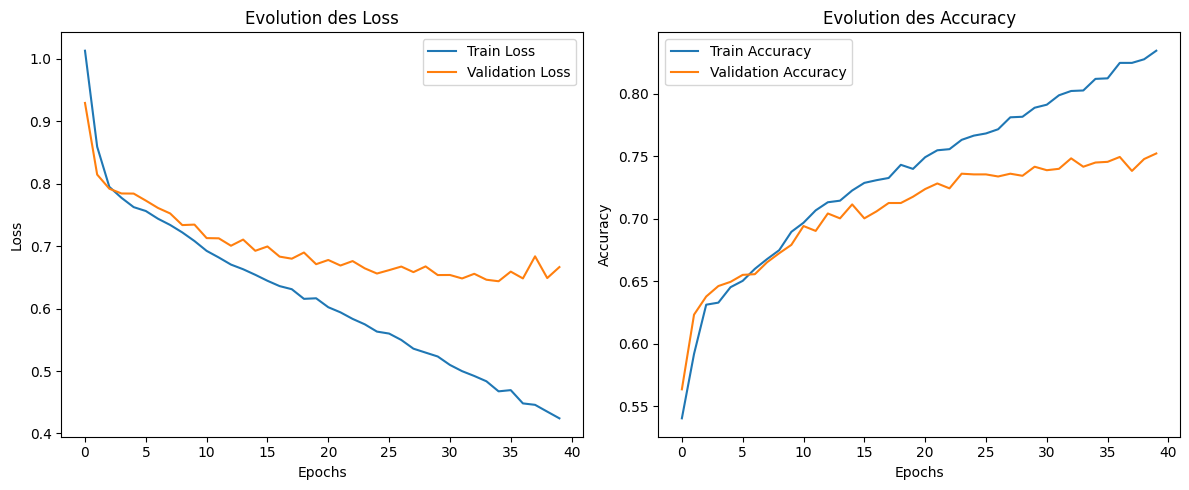

In [ ]:
# courbes d'apprentissage
plot_learning_curves(train_losses, val_losses, train_accs, val_accs)

In [ ]:
# evaluation sur le test set
model.eval()
test_loss = 0
test_acc = 0
all_preds = []
all_true = []

with torch.no_grad():
    for batch in test_loader:
        x_batch, y_batch = batch
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)

        y_pred = model(x_batch)
        loss = criterion(y_pred, y_batch)
        acc = calculate_accuracy(y_pred, y_batch)

        test_loss += loss.item()
        test_acc += acc.item()
        all_preds.extend(torch.argmax(y_pred, 1).cpu().numpy())
        all_true.extend(y_batch.cpu().numpy())

rapport de classification 

              precision    recall  f1-score   support

    negative       0.73      0.62      0.67       703
     neutral       0.63      0.60      0.61       808
    positive       0.82      0.88      0.85      1978

    accuracy                           0.77      3489
   macro avg       0.73      0.70      0.71      3489
weighted avg       0.76      0.77      0.76      3489



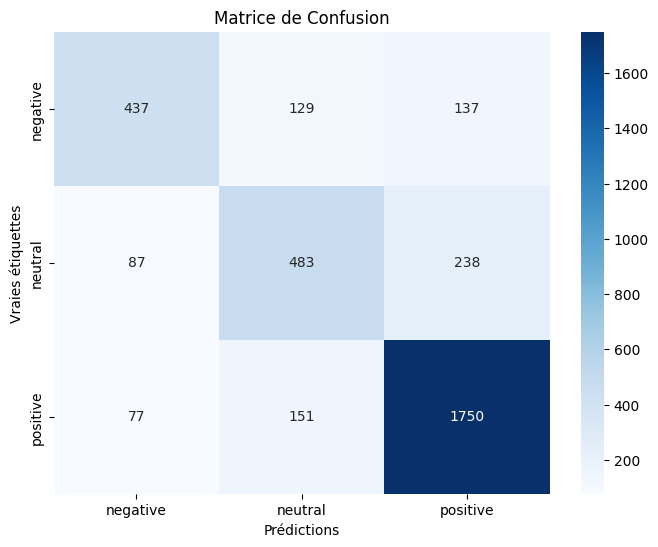

In [ ]:
# rapport et matrice
print_classification_report(all_true, all_preds, target_names=label_encoder.classes_)
plot_confusion_matrix(all_true, all_preds, classes=label_encoder.classes_)

In [ ]:
# fonction de prediction
def predict_from_texts(texts):
    embeddings = compute_bert_embeddings(texts, tokenizer, bert_model, device)
    embeddings = embeddings.unsqueeze(1).to(device)  # (batch, seq_len=1, input_dim)
    with torch.no_grad():
        outputs = model(embeddings)
        preds_idx = torch.argmax(outputs, dim=1).cpu().numpy()
    preds_labels = label_encoder.inverse_transform(preds_idx)
    return preds_labels

# exemple d'utilisation
texts_darija = [
    # exemples positifs
    "فرحان بزاف بهاد النتيجة",
    "المساعدة كانت ممتازة وسريعة",
    "شكراً لكم على كل شيء",
    "هذا المنتج رائع وعجبني كثيراً",
    "كنت سعيد بالتجربة ديالي معاكم",

    # exemples negatifs
    "هاد الخدمة خايبة وما عجباتنيش",
    "عندي مشكل مع الهاتف ديالي وما تحلش",
    "ما بغيتش نرجع نستعمل هاد التطبيق",
    "التجربة ديالي كانت سيئة بزاف",
    "ما لقيتش الدعم اللي كنت كنطلبو",
]
predictions = predict_from_texts(texts_darija)
for text, pred in zip(texts_darija, predictions):
    print(f"Texte : {text}\nPrédiction : {pred}\n")

Texte : فرحان بزاف بهاد النتيجة
Prédiction : positive

Texte : المساعدة كانت ممتازة وسريعة
Prédiction : positive

Texte : شكراً لكم على كل شيء
Prédiction : positive

Texte : هذا المنتج رائع وعجبني كثيراً
Prédiction : positive

Texte : كنت سعيد بالتجربة ديالي معاكم
Prédiction : positive

Texte : هاد الخدمة خايبة وما عجباتنيش
Prédiction : neutral

Texte : عندي مشكل مع الهاتف ديالي وما تحلش
Prédiction : neutral

Texte : ما بغيتش نرجع نستعمل هاد التطبيق
Prédiction : neutral

Texte : التجربة ديالي كانت سيئة بزاف
Prédiction : negative

Texte : ما لقيتش الدعم اللي كنت كنطلبو
Prédiction : neutral



## 3.3 Save model BiLSTM

In [ ]:
# definire le chemain (path)
save_path = '/content/drive/MyDrive/Projet_PFE/bilstm_model.pth'

# enregistrer weights du modele
torch.save(model.state_dict(), save_path)

# confirmation
print(f"✅ Model successfully saved to: {save_path}")

✅ Model successfully saved to: /content/drive/MyDrive/Projet_PFE/bilstm_model.pth


## 3.4 GRU

In [ ]:
class GRUClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, num_layers=1, dropout=0.2):
        super(GRUClassifier, self).__init__()
        self.gru = nn.GRU(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=False,
            dropout=dropout if num_layers > 1 else 0
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        gru_out, _ = self.gru(x)
        last_hidden = gru_out[:, -1, :]
        last_hidden = self.dropout(last_hidden)
        output = self.fc(last_hidden)
        return output

# parametres du modele
input_dim = train_embeddings.shape[1]
hidden_dim = 256
output_dim = len(np.unique(y_train))
num_layers = 2
dropout = 0.7

# initialisation du modele
model = GRUClassifier(
    input_dim=input_dim,
    hidden_dim=hidden_dim,
    output_dim=output_dim,
    num_layers=num_layers,
    dropout=dropout
).to(device)

# definir la fonction de perte et l'optimiseur
criterion = nn.CrossEntropyLoss()
optimizer = AdamW(model.parameters(), lr=2e-5)

# preparation des donnees
train_dataset = torch.utils.data.TensorDataset(
    torch.tensor(train_embeddings.numpy(), dtype=torch.float32),
    torch.tensor(y_train, dtype=torch.long)
)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

val_dataset = torch.utils.data.TensorDataset(
    torch.tensor(val_embeddings.numpy(), dtype=torch.float32),
    torch.tensor(y_val, dtype=torch.long)
)

class_counts = np.bincount(y_train)
class_weights = 1. / torch.tensor(class_counts, dtype=torch.float)
samples_weights = class_weights[y_train]

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    sampler=WeightedRandomSampler(
        weights=samples_weights,
        num_samples=len(samples_weights),
        replacement=True
    ),
    drop_last=True
)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)


# fonction pour calculer l'accuracy
def calculate_accuracy(y_pred, y_true):
    _, predicted = torch.max(y_pred, 1)
    correct = (predicted == y_true).float()
    return correct.mean()

# boucle d'entrainement
train_losses = []
val_losses = []
train_accs = []
val_accs = []

num_epochs = 35

for epoch in range(num_epochs):
    model.train()
    epoch_train_loss = 0
    epoch_train_acc = 0

    for batch in tqdm(train_loader, desc=f"Epoch {epoch + 1}/{num_epochs}"):
        inputs, labels = batch
        inputs, labels = inputs.unsqueeze(1).to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        acc = calculate_accuracy(outputs, labels)

        loss.backward()
        optimizer.step()

        epoch_train_loss += loss.item()
        epoch_train_acc += acc.item()

    avg_train_loss = epoch_train_loss / len(train_loader)
    avg_train_acc = epoch_train_acc / len(train_loader)
    train_losses.append(avg_train_loss)
    train_accs.append(avg_train_acc)

    # validation
    model.eval()
    epoch_val_loss = 0
    epoch_val_acc = 0

    with torch.no_grad():
        for batch in val_loader:
            inputs, labels = batch
            inputs, labels = inputs.unsqueeze(1).to(device), labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)
            acc = calculate_accuracy(outputs, labels)

            epoch_val_loss += loss.item()
            epoch_val_acc += acc.item()

    avg_val_loss = epoch_val_loss / len(val_loader)
    avg_val_acc = epoch_val_acc / len(val_loader)
    val_losses.append(avg_val_loss)
    val_accs.append(avg_val_acc)

    print(f"Epoch {epoch + 1}/{num_epochs}")
    print(f"Train Loss: {avg_train_loss:.4f} | Train Acc: {avg_train_acc*100:.2f}%")
    print(f"Val Loss: {avg_val_loss:.4f} | Val Acc: {avg_val_acc*100:.2f}%")
    print("-" * 50)



Epoch 1/35: 100%|██████████| 190/190 [00:00<00:00, 257.48it/s]


Epoch 1/35
Train Loss: 1.0855 | Train Acc: 39.42%
Val Loss: 1.0420 | Val Acc: 65.51%
--------------------------------------------------


Epoch 2/35: 100%|██████████| 190/190 [00:00<00:00, 272.06it/s]


Epoch 2/35
Train Loss: 1.0307 | Train Acc: 50.77%
Val Loss: 0.9603 | Val Acc: 68.53%
--------------------------------------------------


Epoch 3/35: 100%|██████████| 190/190 [00:00<00:00, 271.94it/s]


...

Epoch 33/35
Train Loss: 0.5470 | Train Acc: 77.75%
Val Loss: 0.5398 | Val Acc: 78.63%
--------------------------------------------------


Epoch 34/35: 100%|██████████| 190/190 [00:00<00:00, 267.52it/s]


Epoch 34/35
Train Loss: 0.5553 | Train Acc: 77.21%
Val Loss: 0.5391 | Val Acc: 78.46%
--------------------------------------------------


Epoch 35/35: 100%|██████████| 190/190 [00:00<00:00, 268.01it/s]


Epoch 35/35
Train Loss: 0.5472 | Train Acc: 78.25%
Val Loss: 0.5289 | Val Acc: 78.74%
--------------------------------------------------


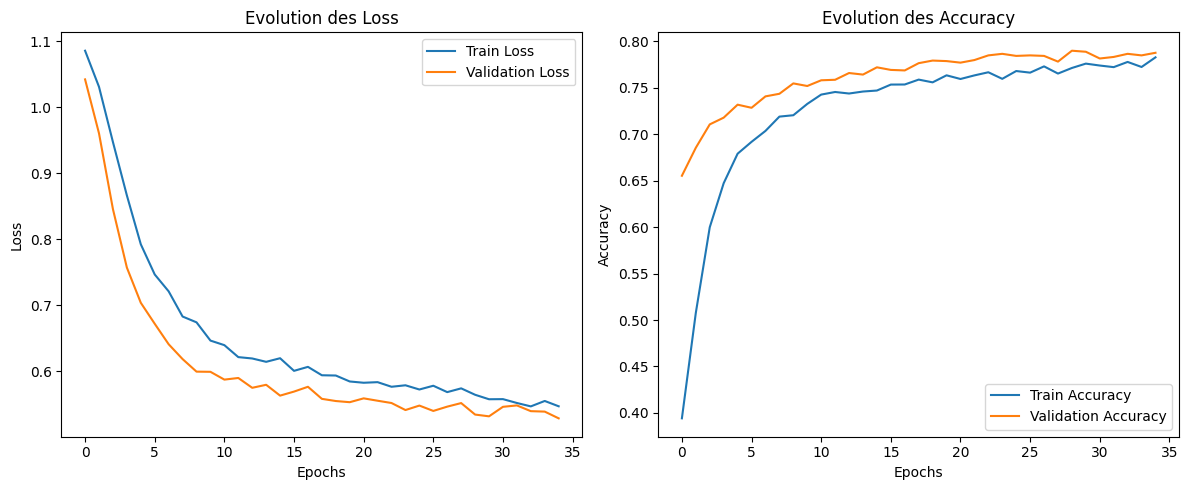

In [ ]:
# courbes d'apprentissage
plot_learning_curves(train_losses, val_losses, train_accs, val_accs)

rapport de classification 

              precision    recall  f1-score   support

    negative       0.72      0.79      0.76       339
     neutral       0.62      0.75      0.68       416
    positive       0.92      0.80      0.86       989

    accuracy                           0.79      1744
   macro avg       0.75      0.78      0.76      1744
weighted avg       0.81      0.79      0.80      1744



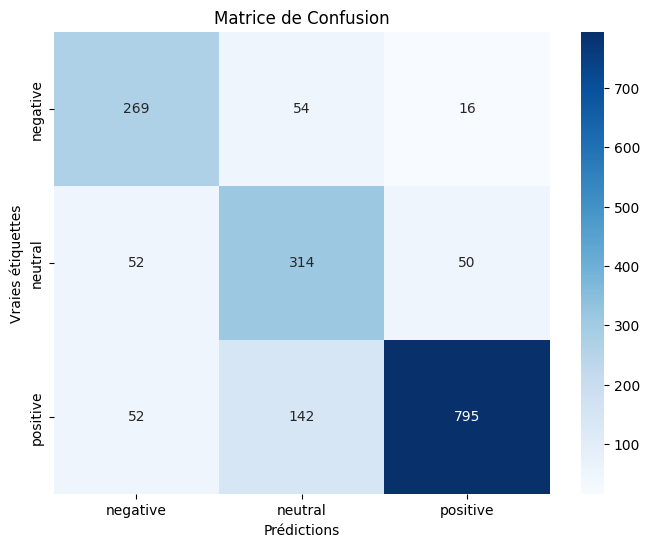

In [ ]:
# evaluation finale sur l'ensemble de validation
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for batch in val_loader:
        inputs, labels = batch
        inputs, labels = inputs.unsqueeze(1).to(device), labels.to(device)

        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# rapport et matrice
print_classification_report(all_labels, all_preds, target_names=label_encoder.classes_)
plot_confusion_matrix(all_labels, all_preds, classes=label_encoder.classes_)

In [ ]:
# fonction de prediction
def predict_from_texts(texts):
    embeddings = compute_bert_embeddings(texts, tokenizer, bert_model, device)
    embeddings = embeddings.unsqueeze(1).to(device)  # (batch, seq_len=1, input_dim)
    with torch.no_grad():
        outputs = model(embeddings)
        preds_idx = torch.argmax(outputs, dim=1).cpu().numpy()
    preds_labels = label_encoder.inverse_transform(preds_idx)
    return preds_labels

# exemple d’utilisation
texts_darija = [
    # exemples positifs
    "فرحان بزاف بهاد النتيجة",
    "المساعدة كانت ممتازة وسريعة",
    "شكراً لكم على كل شيء",
    "هذا المنتج رائع وعجبني كثيراً",
    "كنت سعيد بالتجربة ديالي معاكم",

    # exemples negatifs
    "هاد الخدمة خايبة وما عجباتنيش",
    "عندي مشكل مع الهاتف ديالي وما تحلش",
    "ما بغيتش نرجع نستعمل هاد التطبيق",
    "التجربة ديالي كانت سيئة بزاف",
    "ما لقيتش الدعم اللي كنت كنطلبو",
]
predictions = predict_from_texts(texts_darija)
for text, pred in zip(texts_darija, predictions):
    print(f"Texte : {text}\nPrédiction : {pred}\n")

Texte : فرحان بزاف بهاد النتيجة
Prédiction : positive

Texte : المساعدة كانت ممتازة وسريعة
Prédiction : positive

Texte : شكراً لكم على كل شيء
Prédiction : positive

Texte : هذا المنتج رائع وعجبني كثيراً
Prédiction : positive

Texte : كنت سعيد بالتجربة ديالي معاكم
Prédiction : positive

Texte : هاد الخدمة خايبة وما عجباتنيش
Prédiction : neutral

Texte : عندي مشكل مع الهاتف ديالي وما تحلش
Prédiction : neutral

Texte : ما بغيتش نرجع نستعمل هاد التطبيق
Prédiction : neutral

Texte : التجربة ديالي كانت سيئة بزاف
Prédiction : negative

Texte : ما لقيتش الدعم اللي كنت كنطلبو
Prédiction : neutral



## 3.5 SVM


Training SVM model...
Validation Accuracy (SVM): 80.45%
Test Accuracy (SVM): 79.79%


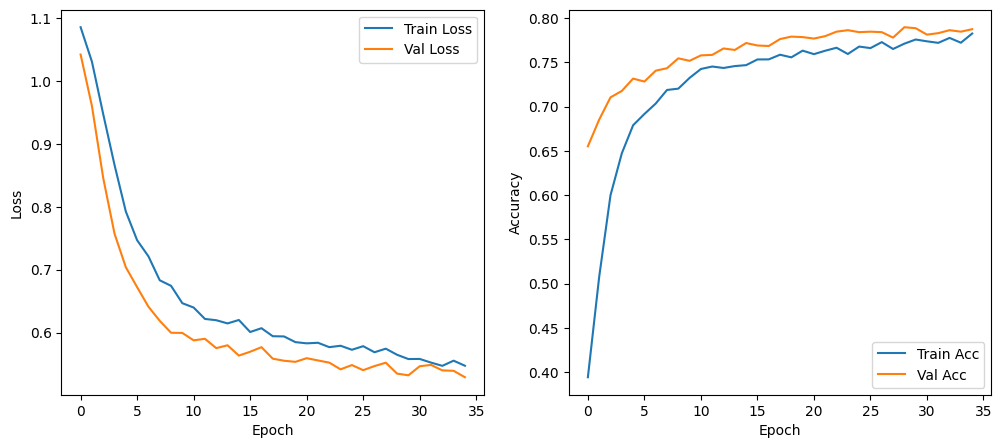


Classification Report for SVM:
              precision    recall  f1-score   support

    negative       0.74      0.74      0.74       703
     neutral       0.67      0.65      0.66       808
    positive       0.87      0.88      0.87      1978

    accuracy                           0.80      3489
   macro avg       0.76      0.76      0.76      3489
weighted avg       0.80      0.80      0.80      3489



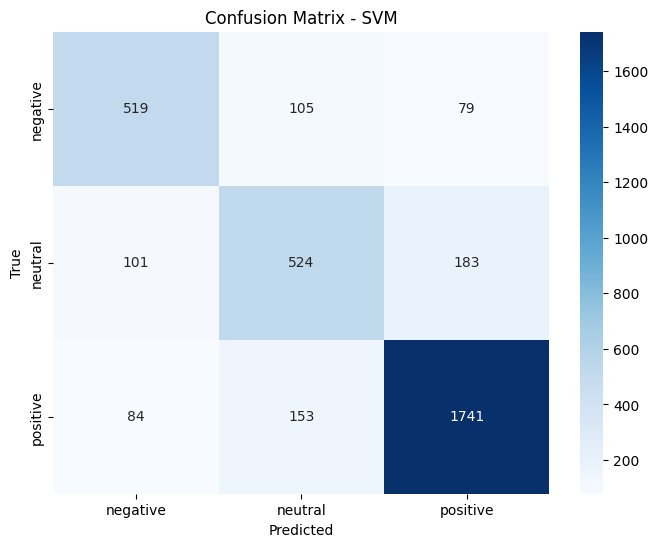

In [ ]:

print("\nTraining SVM model...")

# convertir les tenseurs PyTorch en tableaux numpy pour SVM
X_train_np = train_embeddings.numpy()
X_val_np = val_embeddings.numpy()
X_test_np = test_embeddings.numpy()

# creer et entrainer le modele SVM
svm_model = SVC(kernel='linear', C=1.0, random_state=42)
svm_model.fit(X_train_np, y_train)

# evaluation sur l'ensemble de validation
val_preds_svm = svm_model.predict(X_val_np)
val_acc_svm = accuracy_score(y_val, val_preds_svm)
print(f"Validation Accuracy (SVM): {val_acc_svm*100:.2f}%")

# evaluation sur l'ensemble de test
test_preds_svm = svm_model.predict(X_test_np)
test_acc_svm = accuracy_score(y_test, test_preds_svm)
print(f"Test Accuracy (SVM): {test_acc_svm*100:.2f}%")

# courbes d'apprentissage
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accs, label='Train Acc')
plt.plot(val_accs, label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# rapport et matrice
print("\n rapport de classification:")
print(classification_report(y_test, test_preds_svm, target_names=class_names))

plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, test_preds_svm),
            annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Matrice de confusion ')
plt.show()

In [ ]:
# fonction de prediction
def predict_svm(texts):
    embeddings = compute_bert_embeddings(texts, tokenizer, bert_model, device='cpu')
    preds_idx = svm_model.predict(embeddings)
    preds_labels = label_encoder.inverse_transform(preds_idx)
    return preds_labels

# exemple d’utilisation
texts_darija = [
    # exemples positifs
    "فرحان بزاف بهاد النتيجة",
    "المساعدة كانت ممتازة وسريعة",
    "شكراً لكم على كل شيء",
    "هذا المنتج رائع وعجبني كثيراً",
    "كنت سعيد بالتجربة ديالي معاكم",

    # exemples negatifs
    "هاد الخدمة خايبة وما عجباتنيش",
    "عندي مشكل مع الهاتف ديالي وما تحلش",
    "ما بغيتش نرجع نستعمل هاد التطبيق",
    "التجربة ديالي كانت سيئة بزاف",
    "ما لقيتش الدعم اللي كنت كنطلبو",
]

predictions = predict_svm(texts_darija)
for txt, pred in zip(texts_darija, predictions):
    print(f"Texte : {txt}\nPrédiction : {pred}\n")

Texte : فرحان بزاف بهاد النتيجة
Prédiction : positive

Texte : المساعدة كانت ممتازة وسريعة
Prédiction : positive

Texte : شكراً لكم على كل شيء
Prédiction : positive

Texte : هذا المنتج رائع وعجبني كثيراً
Prédiction : positive

Texte : كنت سعيد بالتجربة ديالي معاكم
Prédiction : neutral

Texte : هاد الخدمة خايبة وما عجباتنيش
Prédiction : negative

Texte : عندي مشكل مع الهاتف ديالي وما تحلش
Prédiction : neutral

Texte : ما بغيتش نرجع نستعمل هاد التطبيق
Prédiction : positive

Texte : التجربة ديالي كانت سيئة بزاف
Prédiction : negative

Texte : ما لقيتش الدعم اللي كنت كنطلبو
Prédiction : neutral



## 3.6 CNN

In [ ]:
def compute_bert_embeddingsCNN(texts, tokenizer, bert_model, device, max_len=128, batch_size=16):
    bert_model = bert_model.to(device)
    bert_model.eval()
    all_embeddings = []
    all_attention_masks = []

    # desactive les calculs de gradient pour economiser de la memoire
    with torch.no_grad():
        for i in range(0, len(texts), batch_size):
            batch_texts = texts[i:i + batch_size]

            # tokenization (sur CPU)
            encoding = tokenizer(
                batch_texts,
                truncation=True,
                padding='max_length',
                max_length=max_len,
                return_tensors='pt'
            )

            # deplacement des donnees vers le GPU en une seule fois
            input_ids = encoding['input_ids'].to(device)
            attention_mask = encoding['attention_mask'].to(device)

            # calcul des embeddings sur GPU
            outputs = bert_model(input_ids=input_ids, attention_mask=attention_mask)

            # conservation des tensors sur GPU pour les operations suivantes
            all_embeddings.append(outputs.last_hidden_state)
            all_attention_masks.append(attention_mask)

    # concatenation sur GPU avant de retourner
    return torch.cat(all_embeddings, dim=0), torch.cat(all_attention_masks, dim=0)

# definir le device une seule fois au debut du code
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


# calcul des embeddings (resultats restent sur GPU)
train_embeddings, train_masks = compute_bert_embeddingsCNN(x_train, tokenizer, bert_model, device)
val_embeddings, val_masks = compute_bert_embeddingsCNN(x_val, tokenizer, bert_model, device)
test_embeddings, test_masks = compute_bert_embeddingsCNN(x_test, tokenizer, bert_model, device)



Using device: cuda


In [ ]:
class CNN1DClassifier(nn.Module):
    def __init__(self, embedding_dim, num_filters, filter_sizes, output_dim, dropout):
        super().__init__()

        self.convs = nn.ModuleList([
            nn.Conv1d(in_channels=embedding_dim,
                     out_channels=num_filters,
                     kernel_size=fs)
            for fs in filter_sizes
        ])

        self.fc = nn.Linear(len(filter_sizes) * num_filters, output_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, embedded, attention_mask=None):
        embedded = embedded.permute(0, 2, 1)

        conved = [F.relu(conv(embedded)) for conv in self.convs]
        pooled = [F.max_pool1d(conv, conv.shape[2]).squeeze(2) for conv in conved]

        cat = self.dropout(torch.cat(pooled, dim=1))
        return self.fc(cat)



class EmbeddingDataset(Dataset):
    def __init__(self, embeddings, masks, labels, device):
        self.embeddings = embeddings
        self.masks = masks
        self.labels = torch.tensor(labels, dtype=torch.long).to(device)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.embeddings[idx], self.masks[idx], self.labels[idx]

# creation des datasets
train_dataset = EmbeddingDataset(train_embeddings, train_masks, y_train, device)
val_dataset = EmbeddingDataset(val_embeddings, val_masks, y_val, device)
test_dataset = EmbeddingDataset(test_embeddings, test_masks, y_test, device)


def train(model, iterator, optimizer, criterion, device):
    model.train()
    epoch_loss = 0
    epoch_acc = 0

    for batch in tqdm(iterator, desc="Training"):
        embeddings, masks, labels = batch
        embeddings, masks, labels = embeddings.to(device), masks.to(device), labels.to(device)

        optimizer.zero_grad()
        predictions = model(embeddings, masks)
        loss = criterion(predictions, labels)
        acc = accuracy_score(labels.cpu(), predictions.argmax(dim=1).cpu())

        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        epoch_acc += acc

    return epoch_loss / len(iterator), epoch_acc / len(iterator)

def evaluate(model, iterator, criterion, device):
    model.eval()
    epoch_loss = 0
    epoch_acc = 0

    with torch.no_grad():
        for batch in tqdm(iterator, desc="Evaluating"):
            embeddings, masks, labels = batch
            embeddings, masks, labels = embeddings.to(device), masks.to(device), labels.to(device)

            predictions = model(embeddings, masks)
            loss = criterion(predictions, labels)
            acc = accuracy_score(labels.cpu(), predictions.argmax(dim=1).cpu())

            epoch_loss += loss.item()
            epoch_acc += acc

    return epoch_loss / len(iterator), epoch_acc / len(iterator)

# les paramètres du modele
EMBEDDING_DIM = 768
NUM_FILTERS = 100
FILTER_SIZES = [3, 4, 5]
OUTPUT_DIM = len(np.unique(y_train))
DROPOUT = 0.7
BATCH_SIZE = 64
LEARNING_RATE = 2e-5
N_EPOCHS = 32

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

#  creation des DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

#  initialisation du modele
model = CNN1DClassifier(
    embedding_dim=EMBEDDING_DIM,
    num_filters=NUM_FILTERS,
    filter_sizes=FILTER_SIZES,
    output_dim=OUTPUT_DIM,
    dropout=DROPOUT
).to(device)

#  optimiseur et fonction de perte
optimizer = AdamW(model.parameters(), lr=LEARNING_RATE)
criterion = nn.CrossEntropyLoss()

#  verification des DataLoaders
print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")


train_losses = []
train_accs = []
val_losses = []
val_accs = []
best_valid_loss = float('inf')

# boucle d'entrainement
for epoch in range(N_EPOCHS):
    train_loss, train_acc = train(model, train_loader, optimizer, criterion, device)
    valid_loss, valid_acc = evaluate(model, val_loader, criterion, device)


    train_losses.append(train_loss)
    train_accs.append(train_acc)
    val_losses.append(valid_loss)
    val_accs.append(valid_acc)

    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        torch.save(model.state_dict(), 'best_model_cnn1d.pt')

    print(f'\nEpoch: {epoch+1:02}')
    print(f'\tTrain Loss: {train_loss:.3f} | Train Acc: {train_acc*100:.2f}%')
    print(f'\t Val. Loss: {valid_loss:.3f} |  Val. Acc: {valid_acc*100:.2f}%')


Using device: cuda
Train batches: 191
Val batches: 28


Evaluating: 100%|██████████| 28/28 [00:00<00:00, 141.86it/s]



Epoch: 01
	Train Loss: 0.894 | Train Acc: 60.95%
	 Val. Loss: 0.651 |  Val. Acc: 71.48%


Evaluating: 100%|██████████| 28/28 [00:00<00:00, 151.91it/s]



Epoch: 02
	Train Loss: 0.660 | Train Acc: 71.60%
	 Val. Loss: 0.583 |  Val. Acc: 76.45%


...


Epoch: 30
	Train Loss: 0.300 | Train Acc: 89.58%
	 Val. Loss: 0.411 |  Val. Acc: 84.26%


Evaluating: 100%|██████████| 28/28 [00:00<00:00, 148.27it/s]



Epoch: 31
	Train Loss: 0.294 | Train Acc: 89.80%
	 Val. Loss: 0.409 |  Val. Acc: 84.54%


Evaluating: 100%|██████████| 28/28 [00:00<00:00, 138.86it/s]


Epoch: 32
	Train Loss: 0.288 | Train Acc: 90.33%
	 Val. Loss: 0.408 |  Val. Acc: 84.26%


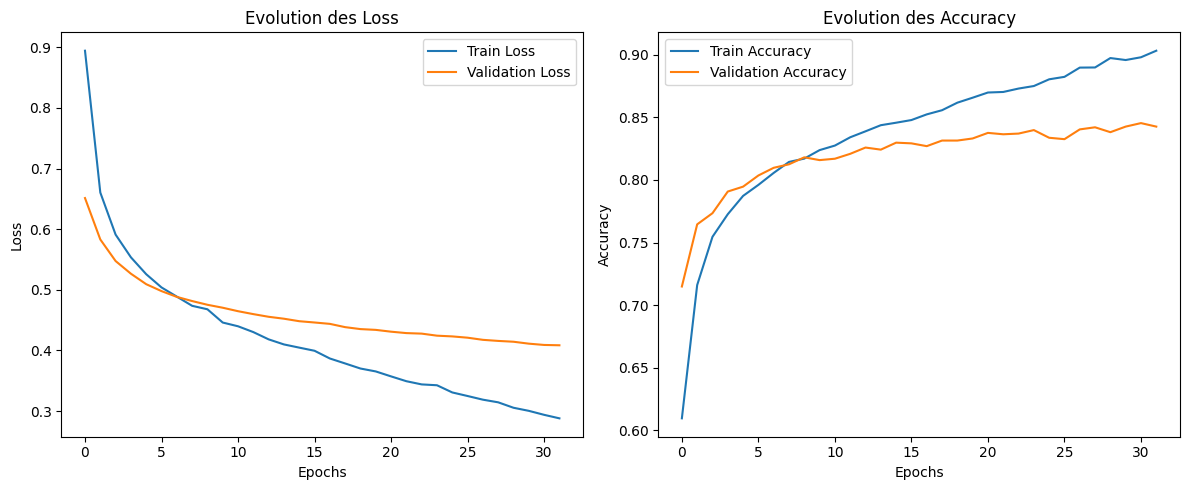

In [ ]:
# courbes d'apprentissage
plot_learning_curves(train_losses, val_losses, train_accs, val_accs)

Evaluating: 100%|██████████| 55/55 [00:00<00:00, 136.93it/s]


Test Loss: 0.406 | Test Acc: 84.30%
              precision    recall  f1-score   support

    negative       0.82      0.79      0.81       703
     neutral       0.74      0.74      0.74       808
    positive       0.89      0.91      0.90      1978

    accuracy                           0.84      3489
   macro avg       0.82      0.81      0.81      3489
weighted avg       0.84      0.84      0.84      3489



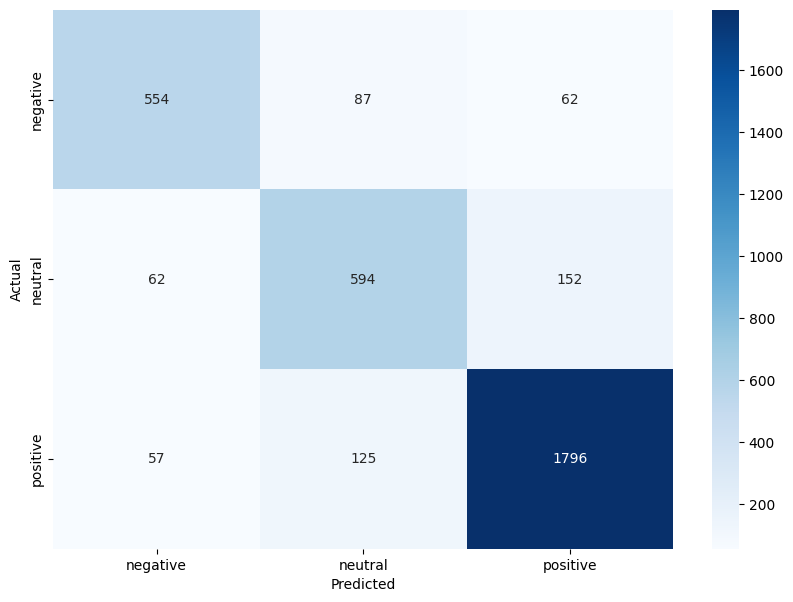

In [ ]:
model.load_state_dict(torch.load('best_model_cnn1d.pt'))
test_loss, test_acc = evaluate(model, test_loader, criterion, device)
print(f'Test Loss: {test_loss:.3f} | Test Acc: {test_acc*100:.2f}%')

# rapport de classification
def get_predictions(model, iterator, device):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in iterator:
            embeddings, masks, labels = batch
            embeddings, masks, labels = embeddings.to(device), masks.to(device), labels.to(device)

            predictions = model(embeddings, masks)
            all_preds.extend(predictions.argmax(dim=1).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return all_labels, all_preds

test_labels, test_preds = get_predictions(model, test_loader, device)
print(classification_report(test_labels, test_preds, target_names=label_encoder.classes_))

# matrice de confusion
conf_mat = confusion_matrix(test_labels, test_preds)
plt.figure(figsize=(10,7))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
# fonction de prediction
def predict_cnn(texts):
    embeddings, attention_masks = compute_bert_embeddingsCNN(texts, tokenizer, bert_model, device)
    embeddings = embeddings.to(device)
    with torch.no_grad():
        outputs = model(embeddings)
        preds_idx = torch.argmax(outputs, dim=1).cpu().numpy()
    preds_labels = label_encoder.inverse_transform(preds_idx)
    return preds_labels

#  exemple d'utilisation
texts_darija = [
    # exemples positifs
    "فرحان بزاف بهاد النتيجة",
    "المساعدة كانت ممتازة وسريعة",
    "شكراً لكم على كل شيء",
    "هذا المنتج رائع وعجبني كثيراً",
    "كنت سعيد بالتجربة ديالي معاكم",

    # exemples negatifs
    "هاد الخدمة خايبة وما عجباتنيش",
    "عندي مشكل مع الهاتف ديالي وما تحلش",
    "ما بغيتش نرجع نستعمل هاد التطبيق",
    "التجربة ديالي كانت سيئة بزاف",
    "ما لقيتش الدعم اللي كنت كنطلبو",
]

predictions = predict_cnn(texts_darija)
for text, pred in zip(texts_darija, predictions):
    print(f"Texte : {text}\nPrédiction : {pred}\n")

Texte : فرحان بزاف بهاد النتيجة
Prédiction : positive

Texte : المساعدة كانت ممتازة وسريعة
Prédiction : positive

Texte : شكراً لكم على كل شيء
Prédiction : positive

Texte : هذا المنتج رائع وعجبني كثيراً
Prédiction : positive

Texte : كنت سعيد بالتجربة ديالي معاكم
Prédiction : positive

Texte : هاد الخدمة خايبة وما عجباتنيش
Prédiction : negative

Texte : عندي مشكل مع الهاتف ديالي وما تحلش
Prédiction : neutral

Texte : ما بغيتش نرجع نستعمل هاد التطبيق
Prédiction : neutral

Texte : التجربة ديالي كانت سيئة بزاف
Prédiction : negative

Texte : ما لقيتش الدعم اللي كنت كنطلبو
Prédiction : neutral

